# Slope Unit types x landslide inventory - cross-analysis

Companion to `eda_slope_unit_types.ipynb`. Produces the four extra outputs for the
subsubsection *Relationship with the landslide inventory* (Chapter 4):

| # | Output | File |
|---|--------|------|
| T1 | Traceability table of the cross-analysis | `tab_su_inventory.tex` |
| F1 | Frequency Ratio (2 panels) | `fig6b_frequency_ratio.png` |
| F2 | Density heatmap, SU type x rainfall zone | `fig6c_heatmap_type_zone.png` |
| F3 | Choropleth maps of landslide activity per SU | `fig6d_map_activity.png` |

**Input:** `slope_units_final_mm_rain.gpkg` (projected CRS, metres).
Required columns: `su_type`, `n_mm`, `zona_lluvia`, `geometry`.

All the analysis code lives in `su_crosscheck.py`, kept next to this notebook.

In [2]:
import os
import importlib

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

import su_crosscheck as sc
importlib.reload(sc)   # re-run this cell after editing su_crosscheck.py

# ------------------------------------------------------------------
# Paths (same convention as eda_slope_unit_types.ipynb)
# ------------------------------------------------------------------
GPKG_PATH = "slope_units_final_mm_rain.gpkg"
FIG_DIR   = "figs_eda"
TEX_DIR   = "tex_out"
os.makedirs(FIG_DIR, exist_ok=True)
os.makedirs(TEX_DIR, exist_ok=True)

SAVE_FIGS = True
DPI = 300

# ------------------------------------------------------------------
# Publication style (identical to the EDA notebook)
# ------------------------------------------------------------------
plt.rcParams.update({
    "font.family": "DejaVu Sans", "font.size": 11,
    "axes.titlesize": 13, "axes.titleweight": "bold", "axes.labelsize": 11.5,
    "axes.spines.top": False, "axes.spines.right": False,
    "xtick.labelsize": 10.5, "ytick.labelsize": 10.5,
    "legend.frameon": False, "figure.dpi": 110, "savefig.bbox": "tight",
})

def fig_path(name):
    return os.path.join(FIG_DIR, name) if SAVE_FIGS else None

In [3]:
gdf_raw = gpd.read_file(GPKG_PATH)
gdf = sc.prepare(gdf_raw, type_col="su_type", count_col="n_mm", zone_col="zona_lluvia")

SU x INVENTORY CROSS-ANALYSIS -- input diagnostics
Slope units                 : 61,242
Total area                  : 1,007.0 km2
Total landslides assigned   : 6,198
Units with >=1 landslide    : 4,060 (6.6 %)
Max landslides in one unit  : 29
Units without rainfall zone : 291
Units per rainfall zone     :
    zone 1 (Oriente): 5,771
    zone 2 (Norte): 29,701
    zone 3 (Sur): 14,383
    zone 4 (SAP): 2,606
    zone 5 (Occidente): 8,490
--------------------------------------------------------------------
REPORT THESE IN THE THESIS and fill in by hand:
  * rule used to assign a landslide to a unit (centroid / intersection / crown point)
  * landslides discarded by the slope <= 10 deg filter (needs the pre-filter layer)
  * landslides falling outside the valley boundary


## T1 - Traceability table of the cross-analysis

Reports, per SU type: number of units, area, landslides, density and frequency ratio,
so the reader can reconstruct every number in the text.

$$D_t = \frac{N_t}{A_t}, \qquad FR_t = \frac{N_t/N}{A_t/A} = \frac{D_t}{D_{\text{global}}}$$

Confidence intervals come from a bootstrap over slope units, stratified by type
(2000 replicates). A Poisson interval would be narrower but would ignore the fact
that landslides cluster within units.

In [4]:
tab = sc.traceability_table(gdf)
display(tab.round(3))

# Bootstrap CIs. Lower n_boot to 500 for a quick draft run.
ci = sc.bootstrap_ci(gdf, n_boot=2000, seed=42, chunk=100)

,label,n_units,pct_units,area_km2,pct_area,n_ls,pct_ls,density,fr,pct_affected
su_type,,,,,,,,,,
1,Steep concave-convex slopes,31636,51.657,575.558,57.157,4668,75.315,8.110,1.318,9.277
2,Intermediate concave-convex slopes,23012,37.576,383.844,38.118,1209,19.506,3.150,0.512,3.798
3,Steep concave slopes,6594,10.767,47.576,4.725,321,5.179,6.747,1.096,3.806
0,All slope units,61242,100.000,1006.977,100.000,6198,100.000,6.155,1.000,6.629


Bootstrap: 2000 replicates, stratified by SU type, seed=42
  95% percentile intervals

  density (events/km2):
            lo     hi     se
su_type                     
1        7.739  8.477  0.190
2        2.912  3.409  0.128
3        5.833  7.658  0.461

  frequency ratio:
            lo     hi     se
su_type                     
1        1.290  1.345  0.014
2        0.475  0.549  0.019
3        0.951  1.249  0.075


In [5]:
chi = sc.chi2_area_test(gdf)

# Concentration of the inventory across units (sanity check for the map)
conc = sc.concentration_summary(gdf)
display(conc.round(2))


Chi-square goodness of fit vs. area-proportional null
  chi2 = 923.5  (df = 2)   p < 1e-12
  Cramer's V = 0.273
  SU 1: observed   4668 | expected  3542.6 | contributes  38.7% of chi2
  SU 2: observed   1209 | expected  2362.6 | contributes  61.0% of chi2
  SU 3: observed    321 | expected   292.8 | contributes   0.3% of chi2


,pct_units_affected,pct_ls_in_top5pct_units,gini,max_per_unit
su_type,,,,
1,9.28,70.99,0.94,29
2,3.80,100.00,0.97,11
3,3.81,100.00,0.97,5
0,6.63,83.90,0.95,29


In [6]:
tex = sc.table_to_latex(tab, ci=ci,
                        path=os.path.join(TEX_DIR, "tab_su_inventory.tex"),
                        label="tab:su_inventory")
print(tex)

\begin{table}[H]
    \centering
    \footnotesize
    \begin{tabular}{lrrrrr}
        \hline
        \textbf{Type} & \textbf{Units (\%)} & \textbf{Area km$^{2}$ (\%)} & \textbf{Landslides (\%)} & \textbf{$D_t$ (ev.\,km$^{-2}$)} & \textbf{FR} \\
        \hline
        SU 1 & 31\,636 (51.7) & 575.6 (57.2) & 4\,668 (75.3) & 8.11 [7.74--8.48] & 1.32 [1.29--1.34] \\
        SU 2 & 23\,012 (37.6) & 383.8 (38.1) & 1\,209 (19.5) & 3.15 [2.91--3.41] & 0.51 [0.48--0.55] \\
        SU 3 & 6\,594 (10.8) & 47.6 (4.7) & 321 (5.2) & 6.75 [5.83--7.66] & 1.10 [0.95--1.25] \\
        \hline
        All units & 61\,242 (100.0) & 1007.0 (100.0) & 6\,198 (100.0) & 6.16 & 1.00 \\
        \hline
    \end{tabular}
    \caption{Cross-analysis between the Slope Unit types and the landslide inventory of the Aburra Valley.}
    \label{tab:su_inventory}
\end{table}


## F1 - Frequency Ratio

Panel (a) contrasts the share of valley **area** with the share of **landslides**
held by each type: the gap between the two bars *is* the over- or
under-representation. Panel (b) turns that gap into the frequency ratio, with the
bootstrap interval and the FR = 1 reference line (proportional to area).

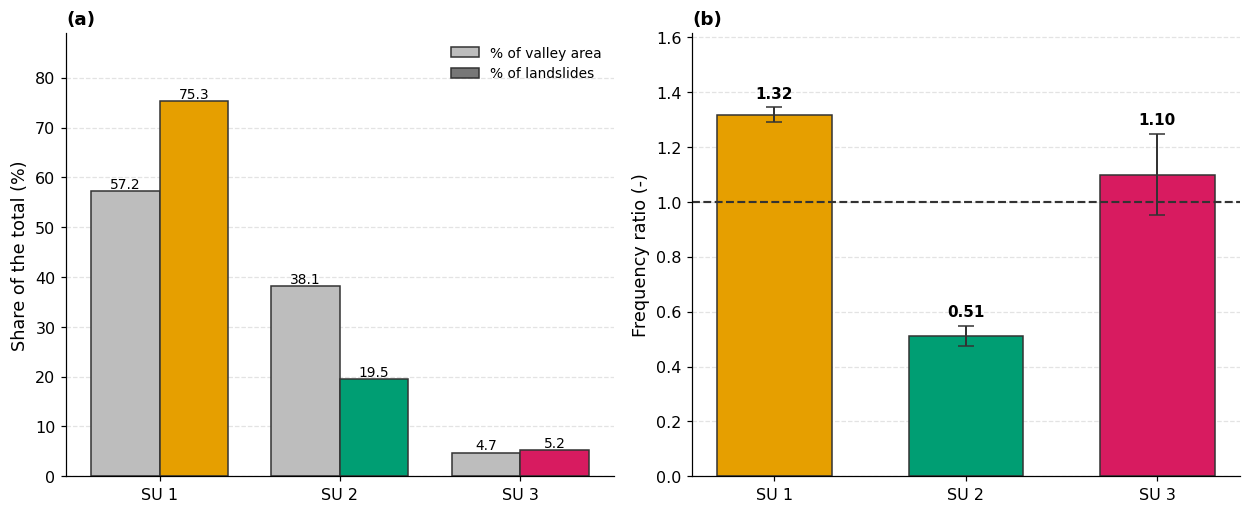

In [7]:
fig = sc.plot_frequency_ratio(tab, ci=ci,
                              savepath=fig_path("fig6b_frequency_ratio.png"),
                              dpi=DPI)
plt.show()

## F2 - Density heatmap: SU type x rainfall zone

The matrix behind the marker sizes of Figures 7-9, shown explicitly. The marginal
row and column are drawn on the same colour scale, so the reader can see whether
the density varies more **down the rows** (slope morphology) or **across the
columns** (rainfall regime). This is the direct evidence for the type x zone
interaction claimed in the Discussion.

Cells with fewer than 30 units or less than 1 km2 are masked as `n.d.`

In [8]:
mats = sc.type_zone_matrix(gdf)

print("Landslide density (events/km2) by type x zone:")
display(mats["density"].round(2))
print("Landslides:")
display(mats["n"].astype("Int64"))
print("Area (km2):")
display(mats["area"].round(1))
print("Units:")
display(mats["n_units"].astype("Int64"))
print(f"Global density: {mats['global_density']:.2f} events/km2")

Landslide density (events/km2) by type x zone:


/home/oisanchezp/Thesis/src/04_Chapter/su_crosscheck.py:432: UserWarning: 291 units have no rainfall zone and are excluded from the type x zone matrix. The marginals of this figure may therefore differ slightly from the totals of the traceability table.
  warnings.warn(f"{n_dropped} units have no rainfall zone and are excluded "


zona_lluvia,1,2,3,4,5
su_type,,,,,
1,7.26,5.33,8.37,15.08,12.88
2,1.36,2.39,4.51,13.58,7.15
3,6.60,4.43,6.79,13.79,9.65


Landslides:


zona_lluvia,1,2,3,4,5
su_type,,,,,
1,174,1386,1331,523,1254
2,94,486,312,59,258
3,13,84,107,53,64


Area (km2):


zona_lluvia,1,2,3,4,5
su_type,,,,,
1,24.0,259.9,158.9,34.7,97.4
2,69.3,203.1,69.2,4.3,36.1
3,2.0,19.0,15.8,3.8,6.6


Units:


zona_lluvia,1,2,3,4,5
su_type,,,,,
1,1390,14659,8347,1834,5349
2,4016,12286,4012,301,2249
3,365,2756,2024,471,892


Global density: 6.17 events/km2


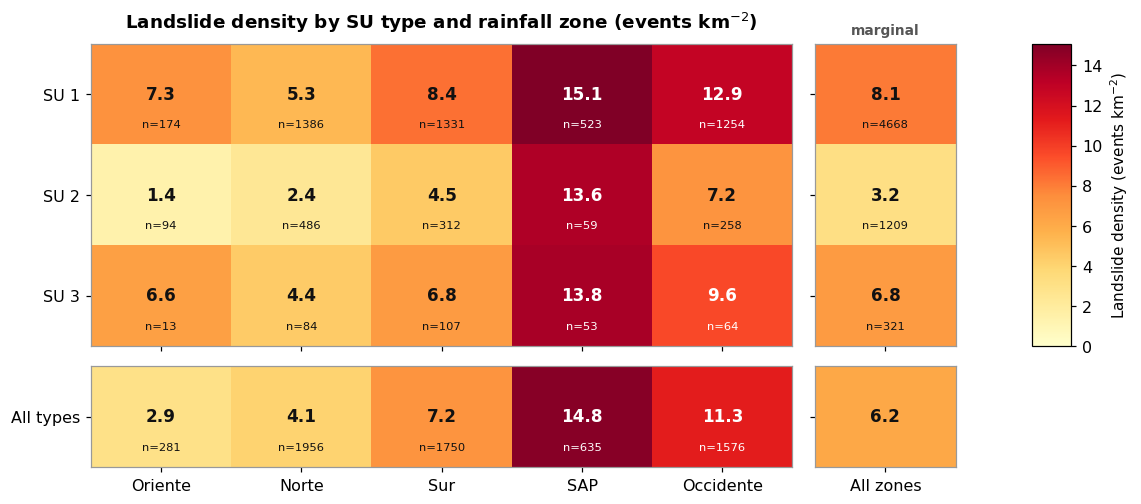

In [9]:
fig = sc.plot_type_zone_heatmap(mats, min_units=30, min_area_km2=1.0,
                                savepath=fig_path("fig6c_heatmap_type_zone.png"),
                                dpi=DPI)
plt.show()

## F3 - Choropleth maps of landslide activity per Slope Unit

Panel (a) shows the raw landslide count per unit. Panel (b) shows the density after
**global Empirical Bayes smoothing** (Marshall, 1991): raw per-unit densities are
meaningless for small units (one landslide in a 0.005 km2 unit gives 200 events/km2),
so each rate is shrunk towards the valley mean by a weight proportional to unit area.

The purpose of this figure is to check whether the aggregate densities reported in
T1 are spatially uniform or driven by a few sectors.

In [10]:
# Dissolving 61k polygons is slow (~1 min). Run once and reuse.
ZONES_PATH = "rainfall_zones_dissolved.gpkg"

if os.path.exists(ZONES_PATH):
    zones_gdf = gpd.read_file(ZONES_PATH)
else:
    tmp = gdf.dropna(subset=["zona_lluvia"]).copy()
    tmp["geometry"] = tmp.geometry.buffer(0)
    zones_gdf = tmp.dissolve(by="zona_lluvia")[["geometry"]].reset_index()
    zones_gdf.to_file(ZONES_PATH, driver="GPKG")

print(zones_gdf)

   zona_lluvia                                           geometry
0            1  MULTIPOLYGON (((836116.807 1174853.620, 836107...
1            2  MULTIPOLYGON (((826349.502 1191876.269, 826347...
2            3  MULTIPOLYGON (((823220.907 1159841.043, 823220...
3            4  POLYGON ((820157.884 1178137.341, 820157.880 1...
4            5  MULTIPOLYGON (((819288.228 1184412.733, 819288...


Empirical Bayes smoothing (Marshall 1991)
  global rate m        = 6.155 events/km2
  prior variance s2    = 272.4696
  shrinkage weight w   : median 0.358, range 0.063-0.878
  raw rate  : max 1,266.5 events/km2
  EB  rate  : max 290.7 events/km2


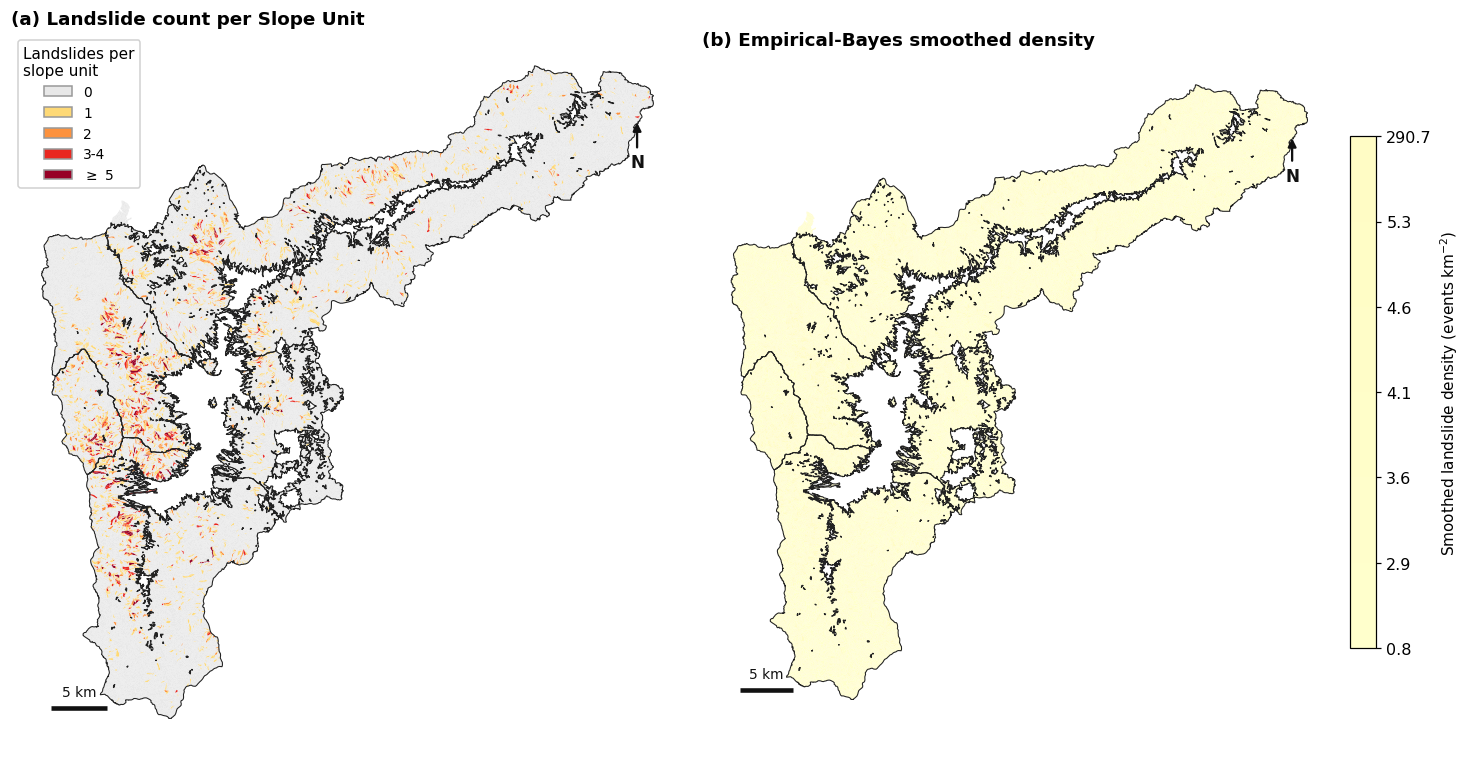

In [11]:
# simplify_m=15 renders in a fraction of the time and is invisible at page scale.
# Set simplify_m=0 for the final publication run.
fig, gmap = sc.plot_activity_maps(gdf,
                                  zone_boundaries=zones_gdf,
                                  simplify_m=15,
                                  n_classes=6,
                                  savepath=fig_path("fig6d_map_activity.png"),
                                  dpi=DPI)
plt.show()

---
## Checks to run before pasting the numbers into the thesis

1. **Unit total.** This layer has **61,242** units, but the chapter reports **61,073**
   in the abstract, in Section `results_su_runs` and in the conclusions. The per-type
   counts (31,636 / 23,012 / 6,594) sum to 61,242 and match the reported percentages,
   so 61,242 is the correct figure. Fix the three occurrences.
2. **Assignment rule.** Confirm how `n_mm` was built (centroid, intersection, crown
   point) and state it in the Methods. Landslides that straddle a divide can be
   counted in the adjacent unit.
3. **Coverage.** Count how many inventory landslides fall outside the retained units
   (slope <= 10 deg filter, valley boundary). Needs the pre-filter layer.
4. **Zone labels.** `ZONE_LABELS` in `su_crosscheck.py` is a guess taken from the EDA
   notebook. Verify against Chapter 3.
5. **SU 3 wording.** Check whether the bootstrap interval of FR for SU 3 excludes 1.
   If it does not, soften the *hotspot* wording in the Results and the Discussion.